<a href="https://colab.research.google.com/github/masoomzehrazaidi/MZZ-demo/blob/main/Stock_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Dense,Dropout

In [3]:
#Download Apple stock data
data=yf.download("AAPL",start="2015-01-01",end="2026-02-20")

/tmp/ipython-input-1497538332.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download("AAPL",start="2015-01-01",end="2026-02-20")
[*********************100%***********************]  1 of 1 completed


In [4]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.214895,24.682228,23.776355,24.671153,212818400
2015-01-05,23.532722,24.064285,23.346676,23.984551,257142000
2015-01-06,23.534931,23.794068,23.173911,23.596947,263188400
2015-01-07,23.864956,23.964623,23.632396,23.743139,160423600
2015-01-08,24.781891,24.839477,24.075355,24.192743,237458000


In [5]:
data = data[['Close']]

In [6]:
data.shape

(2799, 1)

In [7]:
data.head()

Price,Close
Ticker,AAPL
Date,
2015-01-02,24.214895
2015-01-05,23.532722
2015-01-06,23.534931
2015-01-07,23.864956
2015-01-08,24.781891


In [8]:
data.tail()

Price,Close
Ticker,AAPL
Date,
2026-02-12,261.730011
2026-02-13,255.779999
2026-02-17,263.880005
2026-02-18,264.350006
2026-02-19,260.579987


In [9]:
scalar = MinMaxScaler(feature_range=(0,1))
scaled_data = scalar.fit_transform(data)

In [10]:
scaled_data

array([[0.013681  ],
       [0.01111003],
       [0.01111836],
       ...,
       [0.91692679],
       [0.91869812],
       [0.90448974]])

In [11]:
def create_dataset(dataset,time_step=60):
   X,y=[],[]
   for i in range(time_step,len(dataset)):
       X.append(dataset[i-time_step:i,0])
       y.append(dataset[i-0])
   return np.array(X),np.array(y)

time_step =60
X,y = create_dataset(scaled_data,time_step)

In [12]:
X= X.reshape(X.shape[0],X.shape[1],1)

print("X shape:",X.shape)
print("y shape:",y.shape)

X shape: (2739, 60, 1)
y shape: (2739, 1)


In [13]:
train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]


In [14]:
model = Sequential()

model.add(SimpleRNN(units=50,return_sequences=True,input_shape=(X_train.shape[1],1)))
model.add(Dropout(0.2))

model.add(SimpleRNN(units=50))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam',loss='mean_squared_error')

model.summary() #optional

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
X_train.shape[1]

60

In [16]:
history = model.fit(
    X_train,y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test,y_test)
)

Epoch 1/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - loss: 0.0732 - val_loss: 0.0072
Epoch 2/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0087 - val_loss: 0.0041
Epoch 3/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0052 - val_loss: 0.0098
Epoch 4/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0042 - val_loss: 0.0051
Epoch 5/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0032 - val_loss: 0.0013
Epoch 6/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0028 - val_loss: 0.0026
Epoch 7/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0020 - val_loss: 0.0021
Epoch 8/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0019 - val_loss: 0.0022
Epoch 9/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0019 - val_loss: 0.0020
Epoch 10/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0014 - val_loss: 0.0023
Epoch 11/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0014 - val_loss: 0.0010
Epoch 12/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.

In [17]:
predictions = model.predict(X_test)

#Inverse transform to get real price

predictions = scalar.inverse_transform(predictions.reshape(-1,1))
y_test_actual = scalar.inverse_transform(y_test.reshape(-1,1))

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


In [18]:
from sklearn.metrics import mean_absolute_error

mae =  mean_absolute_error(y_test_actual,predictions)
print("MAE:",mae)

MAE: 7.69204709129612


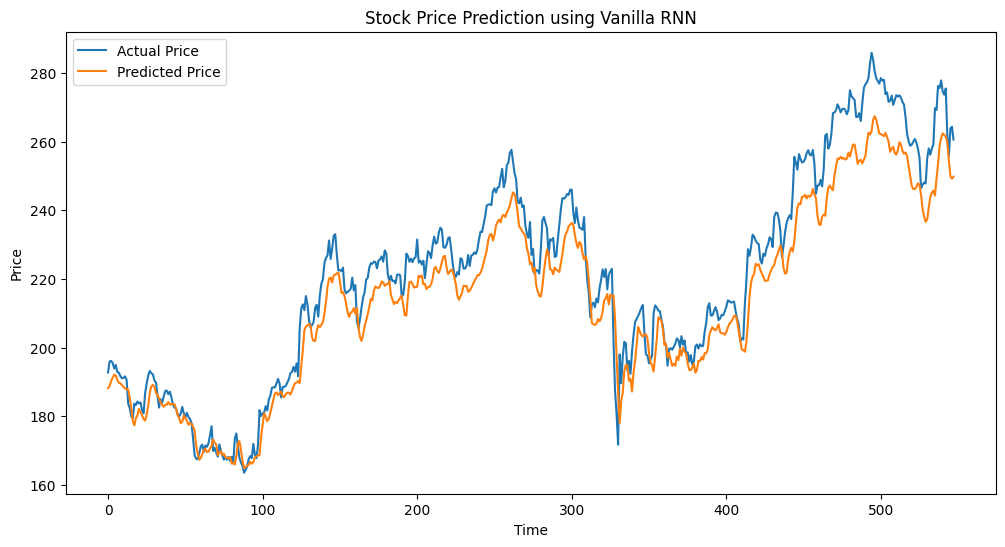

In [19]:
plt.figure(figsize=(12,6))
plt.plot(y_test_actual,label="Actual Price")
plt.plot(predictions,label="Predicted Price")
plt.title("Stock Price Prediction using Vanilla RNN")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

In [20]:
#Get last 60 days from full dataset
last_60_days = scaled_data[-60:]

#Reshape to match RNN input shape
last_60_days = last_60_days.reshape(1,60,1)

In [21]:
#PREDICT NEXT DAY

next_day_scaled = model.predict(last_60_days)

#convert back to original_price
next_day_price = scalar.inverse_transform(next_day_scaled)
print("Predicted Next Day Closing Price:",next_day_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted Next Day Closing Price: 251.6938


In [22]:
price = yf.download("AAPL",period="1d")
price = price[['Close']]
price

/tmp/ipython-input-1846498775.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price = yf.download("AAPL",period="1d")
[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,AAPL
Date,
2026-02-23,266.260101


In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [25]:
model = Sequential()

model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step - loss: 0.0109 - val_loss: 0.0019
Epoch 2/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.0011 - val_loss: 0.0011
Epoch 3/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0010 - val_loss: 0.0019
Epoch 4/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - loss: 9.4487e-04 - val_loss: 0.0010
Epoch 5/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - loss: 0.0011 - val_loss: 0.0027
Epoch 6/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 8.4990e-04 - val_loss: 0.0053
Epoch 7/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 9.3625e-04 - val_loss: 0.0022
Epoch 8/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0011 - val_loss: 0.0047
Epoch 9/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - loss: 7.6695e-04 - val_loss: 0.0018
Epoch 10/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 7.3222e-04 - val_loss: 0.0030
Epoch 11/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 6.6480e-04 - val_loss: 0.0036
Epoch 12/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 

In [34]:
predictions = model.predict(X_test)
predictions = scalar.inverse_transform(predictions.reshape(-1, 1))
y_test_actual = scalar.inverse_transform(y_test.reshape(-1, 1))

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [35]:
mae = mean_absolute_error(y_test_actual, predictions)
print("MAE:", mae)

MAE: 5.405610021883554


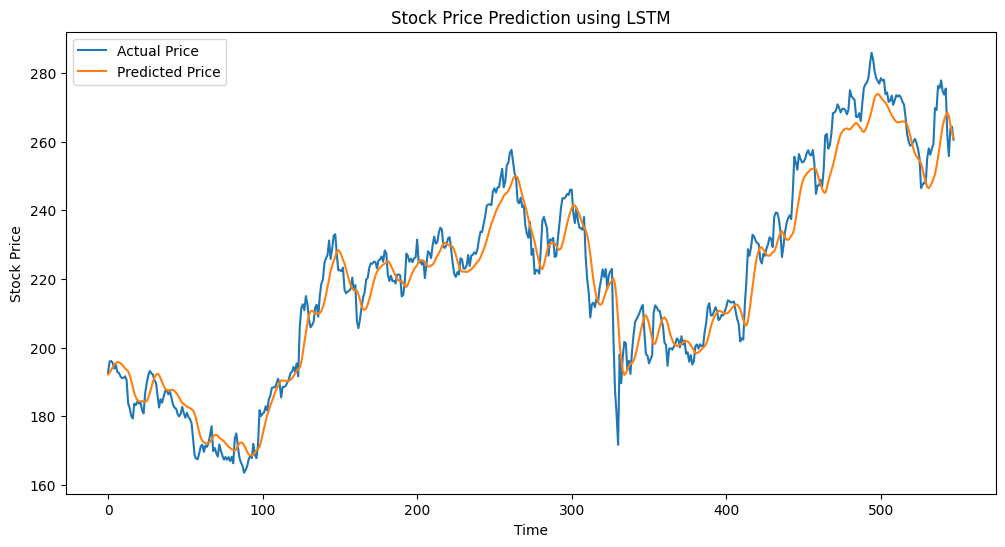

In [36]:
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.title("Stock Price Prediction using LSTM")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

In [37]:
last_60_days = scaled_data[-60:]
last_60_days = last_60_days.reshape(1, 60, 1)

In [39]:
next_day_scaled = model.predict(last_60_days)

next_day_price = scalar.inverse_transform(next_day_scaled)

print("Predicted Next Day Closing Price:", next_day_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted Next Day Closing Price: 259.3687


In [40]:
price = yf.download("AAPL", period="1d")
price = price[["Close"]]

print(price)

/tmp/ipython-input-1942787288.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price = yf.download("AAPL", period="1d")
[*********************100%***********************]  1 of 1 completed

Price           Close
Ticker           AAPL
Date                 
2026-02-23  266.63501
